# AB Test 연습

Kaggle의 데이터를 바탕으로 A/B 테스트를 실습해 보았다.

In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

## Case 1

link : https://www.kaggle.com/datasets/zahrazolghadr/ab-test-cookie-cats

Cookie Cats 라는 모바일 게임의 데이터가 Kaggle에 올라와 있다. 기본적으로는 이 게임은 검색 결과 한붓그리기 게임이다.

### Problem 
이번 문제는 게임 초반의 허들을 변화했을 때 '리텐션'에 어떤 변화가 일어났는지를 보려는 문제이다.
이를 위한 9만명 정도의 데이터가 수집되어 있다.

9만명의 유저는 두 개의 그룹으로 나뉘게 된다.
- 기존안(Group A) : 초기 게이트를 30레벨로 잡았음
- 변경안(Group B) : 초기 게이트를 30레벨->40레벨로 뒤로 미뤘음

어플을 깔아 확인해 본 결과 이것은 게이트, 즉 첫 섹션의 스테이지 개수를 의미한다. 실제로 어플에서 들어가보면, 40스테이지에서 열쇠로 무언가가 잠겨 있다. 이는 별의 개수라던가 친구 초대 등으로 다음 섹션을 열어야 보통 진행이 가능한 구조이다. 즉 처음 플레이할 수 있는 판의 개수를 의미한다.

In [2]:
# text to pandas
df = pd.read_csv('C:/Users/USER/Desktop/TIL_new/data_analyst_practice/cookie_cats.txt', sep = ',')
df.head(5)

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


- retention_1 : D1 Retention의 여부를 살펴보는 것이다.
- retention_7 : D7 Retention의 여부를 살펴보는 것이다.

즉 두 가지 관점이다.
  * D1 : 단기적으로 다시 게임에 들어왔는가 : 즉, 장벽때문에 "못해먹겠어서 접음"이 좀 해소 되었는가?
  * D7 : 좀 더 장기적으로 게임에 들어왔는가 : 즉, 장벽이 뒤로 밀리며 게임 자체가 재밌어져서 장기 유저가 되었는가?

이를 관점으로 분석을 진행하자.

## EDA

<AxesSubplot:xlabel='sum_gamerounds', ylabel='Count'>

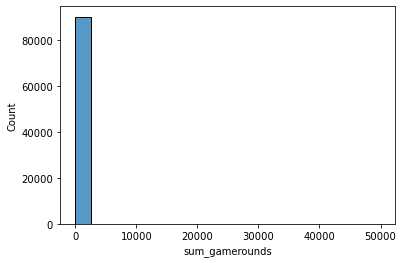

In [3]:
sns.histplot(df['sum_gamerounds'], bins = 20)

In [4]:
df['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

playgrounds라는 변수는 2주동안 몇 번 게임을 플레이했는가?에 대한 변수이다. 아쉽게도 최종 도달 스테이지를 알 수는 없다.

In [5]:
print(sorted(list(df['sum_gamerounds']), reverse = True)[0:10])

[49854, 2961, 2640, 2438, 2294, 2251, 2156, 2124, 2063, 2015]


이상치가 보여서 확인 결과 첫 49854만 유달리 이상한 값이라, 이 값은 제외하자. 2000판 정도는 2주라면..가능할수도.. 4만9천판은 혼자만 튀는 값이라 제외

In [6]:
df = df.loc[df.sum_gamerounds < 3000]

In [7]:
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


1개의 비유효 데이터를 제외하였다.

### 사실...
30 스테이지, 40 스테이지 게이트의 변화를 확인하기 위해서는 gate_30 이면서 30라운드 클리어 유저, gate_40이면서 40라운드 클리어 유저로 확인해야 할 것이다. 거기까지는 가야 해당 장벽을 유의미하게 체험할 것이기 때문이다. 특히 신규 유저의 기준으로는.

### case 1. pure하게 확인

#### retention_1의 변화 체크

우선 데이터 수를 보자.

In [8]:
pd.crosstab(index = df['version'], columns = df['retention_1'])

retention_1,False,True
version,,
gate_30,24665,20034
gate_40,25370,20119


다음과 같이 볼 수 있다. 눈으로는 지표 개선 여부를 확인하기가 어렵다.

#### A/B 테스트 통계 검정

이럴 때, 통계 검정으로 이를 확인해야 한다.

- 귀무가설(H0) : gate를 뒤로 늦춰도 리텐션의 변화에는 효과가 없다. 
- 대립가설(H1) : gate를 뒤로 늦추면 리텐션의 변화에는 효과가 있다.

모두 이 가설을 기준으로 한다.

즉 True 비율에 유의미한 차이가 생겼는가를 보는것이 목표이다.

chi2 검정을 하자.

In [9]:
def click_abtest(a_click, total_a, b_click, total_b):
    click = [a_click, b_click]
    no_click = [total_a-a_click, total_b-b_click]
    chi2, p, dof, expected = scipy.stats.chi2_contingency([click, no_click])
    return p

print(click_abtest(20034, 20034+24665, 20119 ,20119+25370))

0.07500999897705693


p-value가 0.07으로 유의수준 5%보다 큰 값으로, 유의미한 차이가 발생했다고 할 수 없다.

실제로 값을 계산해보면 다음과 같다.

In [10]:
print(20034/(20034+24665))
print(20119/(20119+25370))

0.4481979462627799
0.44228274967574577


유의미한 차이가 없다고 검정되었고 실제로도 0.6% 정도의 차이밖에 존재하지 않는다. 정말 개선되지 않은 것일까?

#### retention_7의 변화 체크

In [11]:
pd.crosstab(index = df['version'], columns = df['retention_7'])

retention_7,False,True
version,,
gate_30,36198,8501
gate_40,37210,8279


역시 눈으로는 알기 어렵다.

In [12]:
print(click_abtest(8501, 8501+36198, 8279, 8279+37210))

0.0016391259678654423


이번에는 유의미한 차이라고 볼 수 있다. 따라서 하락인지 상승인지 다시 파악해보면

In [13]:
print(8501/(8501+36198))
print(8279/(8279+37210))

0.19018322557551623
0.18200004396667327


어..? 리텐션이 유의미하게 떨어졌다... 라고 결론을 내려도 정말 되는 것일까?
하지만 이것은 전체 집단에 대한 통계이다. 퍼즐 게임을 조기 이탈한 유저에 대해서 40탄까지 느끼는 부담이 크다고 해석할 수 있다.
그렇다면 어느정도 정착한 유저들, 게이트에 도달한 유저들의 리텐션 상태는 어떨지 보자.

(사실 이 고객들이 진짜 유의미한 고객들이므로, 이 부분의 해석이 더 중요하다)

### case 2. stage cut

In [14]:
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


사실 클리어 스테이지를 알아야 유효한 판정이 되나, 게이트 이상은 갔다고 판정하는 것으로 갈음한다.

In [15]:
df_condi = df.apply(lambda x: True if (x['version'] == 'gate_30' and x['sum_gamerounds'] >= 30) or
                   (x['version'] == 'gate_40' and x['sum_gamerounds'] >= 40) else False, axis = 1)

In [16]:
df_cut = df.loc[df_condi]

#### ret D1

In [17]:
pd.crosstab(index = df_cut['version'], columns = df_cut['retention_1'])

retention_1,False,True
version,,
gate_30,3314,13341
gate_40,2348,11479


In [18]:
print(click_abtest(13341, 13341+3314, 11479, 11479+2348))

7.828279587432345e-11


유의미하다고 볼 수 있으므로 계산을 해보면

In [19]:
print(13341/(13341+3314))
print(11479/(11479+2348))

0.8010207145001501
0.8301873146741882


오히려 일정 스테이지 이상의 유저들 대상으로는 리텐션의 증가 효과를 얻었다!
즉, 게이트의 확장으로 처음에 플레이 가능한 판 수를 늘려 유저의 초기 경험을 더 좋게 만들었다고 가정 가능하다.

#### ret_D7

In [20]:
pd.crosstab(index = df_cut['version'], columns = df_cut['retention_7'])

retention_7,False,True
version,,
gate_30,9348,7307
gate_40,7120,6707


In [21]:
print(click_abtest(7307, 7307+9348, 6707, 6707+7120))

7.026835904955452e-16


역시 통계적으로 유의미한 차이이므로

In [22]:
print(7307/(7307+9348))
print(6707/(6707+7120))

0.4387271089762834
0.4850654516525638


D7 리텐션에서도 오히려 리텐션 비율이 올라갔다. 즉 일정 판(플레이) 횟수 이상에서는 게이트를 늦춘 것이 오히려 이탈을 방지하고 더 좋은 경험을 가져다 주었다고 볼 수 있다.

실제로 인게임을 보면 전체 유저의 리텐션은 조금 내려가도, 일정 판 이상의 플레이 유저들을 고려하여 결국은 40탄에 게이트가 설치되어 있다. 이 이유를 고려해보면 다음과 걑다.
- 퍼즐 게임의 경우는 일정 판 이상 넘어간 유저를 대상으로 아이템 등의 판매가 일어날 수 있어 일정 판 이상이 유효한 유저이다.
- 한두판 하고 떠날 유저에 대해서는 리텐션이 낮아도 크게 의미가 없다.

### ttest의 활용

위의 경우를 다시 살펴보려고 한다.

스테이지를 넘긴 상태에서의 D1 retention를 다시 보자

이 때의 귀무가설과 대립가설은 one-sided 검정이 됨에 주의하자

In [23]:
# 다음과 같이 t-test를 활용하여 값을 직접 넣어 계산 가능하다.
# 등분산의 보장이 없으므로, 합동 표본표준편차로 t값을 계산 가능하다.
# 즉, 유의미한 개선인지 t-값으로도 확인 가능하다.

def ttest(click_a, total_a, click_b, total_b):
    rate_diff = click_b/total_b - click_a/total_a
    total_prob = (click_a+click_b) / (total_a + total_b)
    std = (total_prob * (1 - total_prob) * (1/total_a + 1/total_b))**0.5
    z_val = rate_diff/std
    rv = scipy.stats.norm(0, 1)
    p_val = 1 - rv.cdf(z_val)
    return z_val, p_val

ttest(13341, 13341+3314, 11479, 11479+2348)


(6.5186552976723995, 3.547018234684174e-11)

z값은 6.5 정도 p-value는 매우 작게 나옴을 알 수 있다. 즉 유의미하게 개선 후의 리텐션이 좋다고 볼 수 있다.

전체 기준의 D7 리텐션을 다시 보면 다음과 같다.

### Feedback

해당 내용에 대해, 피드백을 받은 결과 A/B 테스트는 동일한 집단에서의 랜덤한 구성이어야 하므로 stage를 같은 양 진행한 유저로 측정해야 한다.!

따라서, 30탄 이상 진행한 유저를 대상으로 진행해보자.

In [37]:
df_condi = df['sum_gamerounds'].apply(lambda x: x >= 30)
df_cut = df.loc[df_condi]

In [38]:
pd.crosstab(index = df_cut['version'], columns = df_cut['retention_1'])

retention_1,False,True
version,,
gate_30,3314,13341
gate_40,3292,13321


In [41]:
print(ttest(13341, 3314+13341, 13321, 3292+13321))

(0.18773780108476035, 0.42554109806227036)


유의미한 차이가 있다고 보기는 어렵다.

In [42]:
pd.crosstab(index = df_cut['version'], columns = df_cut['retention_7'])

retention_7,False,True
version,,
gate_30,9348,7307
gate_40,9469,7144


In [43]:
print(ttest(7307, 7307+9348, 7144, 7144+9469))

(-1.601128059662799, 0.945325720742151)


이 경우는 오히려 리텐션이 낮아졌으나, 역시 유의미한 차이는 아니라고 볼 수 있다. 단측 5%에 해당 안된다.